# Read in gene information 

## Reference based positions

In [73]:
genes_ref_pos = {
    "P_protein": [(2308, 3182), (0, 1625)],
    "L_protein": [(2849, 3182), (0, 837)],
    "M_protein": [(3173, 3182), (0, 837)],
    "S_protein": [(156, 837)],
    "X_protein": [(1375, 1840)],
    "PreCore": [(1815, 2454)],
    "Core": [(1902, 2454)],
}

## Conversion to MSA positions

In [84]:
msa = "../data/filtered/MSA_auto_sub500.fasta"
gb  = "../../ingest/defaults/NC_003977.gb"
out = "../data/map_NC_003977_MSA.tsv"

!python map_gb_position_to_msa.py $msa $gb > $out


In [85]:
import csv

# read mapping: gb_pos -> aln_pos
gb2aln = {}

with open("../data/map_NC_003977_MSA.tsv") as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) < 2:
            continue
        if not parts[0].isdigit():
            continue  # skip header / metadata lines

        aln_pos = parts[0]
        gb_pos = parts[1]

        if gb_pos.isdigit():
            gb2aln[int(gb_pos)] = int(aln_pos)
# map genes to MSA positions
genes_MSA_pos = {}

for gene, intervals in genes_ref_pos.items():
    msa_positions = []
    for start, end in intervals:
        for gb_pos in range(start + 1, end + 1):  # gb positions are 1-based
            if gb_pos in gb2aln:
                msa_positions.append(gb2aln[gb_pos])
    genes_MSA_pos[gene] = msa_positions


In [86]:
def to_blocks(pos):
    pos = sorted(set(pos))
    if not pos:
        return []
    blocks = []
    s = e = pos[0]
    for p in pos[1:]:
        if p == e + 1:
            e = p
        else:
            blocks.append((s, e))
            s = e = p
    blocks.append((s, e))
    return blocks

gene_msa_blocks = {g: to_blocks(ps) for g, ps in genes_MSA_pos.items()}


In [88]:
gene_msa_blocks

{'P_protein': [(42, 54),
  (59, 74),
  (78, 78),
  (85, 890),
  (897, 1148),
  (1150, 1176),
  (1178, 1258),
  (1260, 1305),
  (1307, 1374),
  (1376, 1690),
  (2575, 2624),
  (2631, 3122),
  (3124, 3128),
  (3162, 3453),
  (3455, 3488)],
 'L_protein': [(42, 54),
  (59, 74),
  (78, 78),
  (85, 890),
  (897, 897),
  (3122, 3122),
  (3124, 3128),
  (3162, 3453),
  (3455, 3488)],
 'M_protein': [(42, 54),
  (59, 74),
  (78, 78),
  (85, 890),
  (897, 897),
  (3481, 3488)],
 'S_protein': [(211, 890), (897, 897)],
 'X_protein': [(1441, 1709),
  (1798, 1802),
  (1835, 1945),
  (1947, 2006),
  (2043, 2043),
  (2049, 2067)],
 'PreCore': [(2002, 2006),
  (2043, 2043),
  (2049, 2131),
  (2168, 2214),
  (2216, 2259),
  (2261, 2496),
  (2498, 2624),
  (2631, 2726)],
 'Core': [(2130, 2131),
  (2168, 2214),
  (2216, 2259),
  (2261, 2496),
  (2498, 2624),
  (2631, 2726)]}

# Analyse alignment

### Add gene position plotting

In [159]:
import matplotlib.pyplot as plt

def add_annotation_track(fig, ax, annotations, height_ratio=1):
    """
    annotations: list of (start, end, label)
    """
    gs = ax.get_gridspec()
    ax_track = fig.add_subplot(
        gs.new_subplotspec((1, 0), rowspan=1)
    )

    ax_track.sharex(ax)

    colors = plt.cm.tab10.colors

    n = len(annotations)
    ax_track.set_ylim(0, n)

    for i, (label, blocks) in enumerate(annotations.items()):
        y0 = n - i - 0.8
        color = colors[i % len(colors)]

        # draw all blocks for this gene
        for start, end in blocks:
            width = end - start + 1
            ax_track.broken_barh(
                [(start, width)],
                (y0, 0.6),
                facecolors=color
            )

        # label once, after the last segment

        blocks_sorted = sorted(blocks)  # list of (start,end)
        m = len(blocks_sorted)
        L = int(ax.get_xlim()[1])       # alignment length from the shared x-axis

        # compute gaps to the *next* block, including circular wrap (last -> first)
        gaps = []
        for k in range(m):
            e_k = blocks_sorted[k][1]
            s_next = blocks_sorted[(k + 1) % m][0]
            if k < m - 1:
                gap = s_next - e_k - 1
            else:
                gap = (L - e_k) + (blocks_sorted[0][0] - 1)  # wrap gap
            gaps.append(gap)

        k_max = int(np.argmax(gaps))              # block before largest gap
        end_for_label = blocks_sorted[k_max][1]   # label after this block

        # label once, horizontally aligned with bar, using offset in points
        ax_track.annotate(
            label,
            xy=(end_for_label, y0 + 0.3),
            xytext=(8, 0),
            textcoords="offset points",
            ha="left",
            va="center",
            fontsize=12,
            color=color
        )


    ax_track.set_yticks([])
    ax_track.set_xlabel("MSA position")


    return ax_track


## Characterise gaps 

### read in alignment

In [101]:
from Bio import AlignIO
import sys

aln = AlignIO.read("../data/filtered/MSA_auto_sub500.fasta", "fasta")

gap_chars = {"-", "."}
print(aln.get_alignment_length())

counts = []
for i in range(aln.get_alignment_length()):
    n = sum(1 for rec in aln if rec.seq[i] not in gap_chars)
    counts.append(n)

nseq = len(aln)
rel = [c / nseq for c in counts]


3491


### <span style="color: green;"> non-gap sequences per position</span>


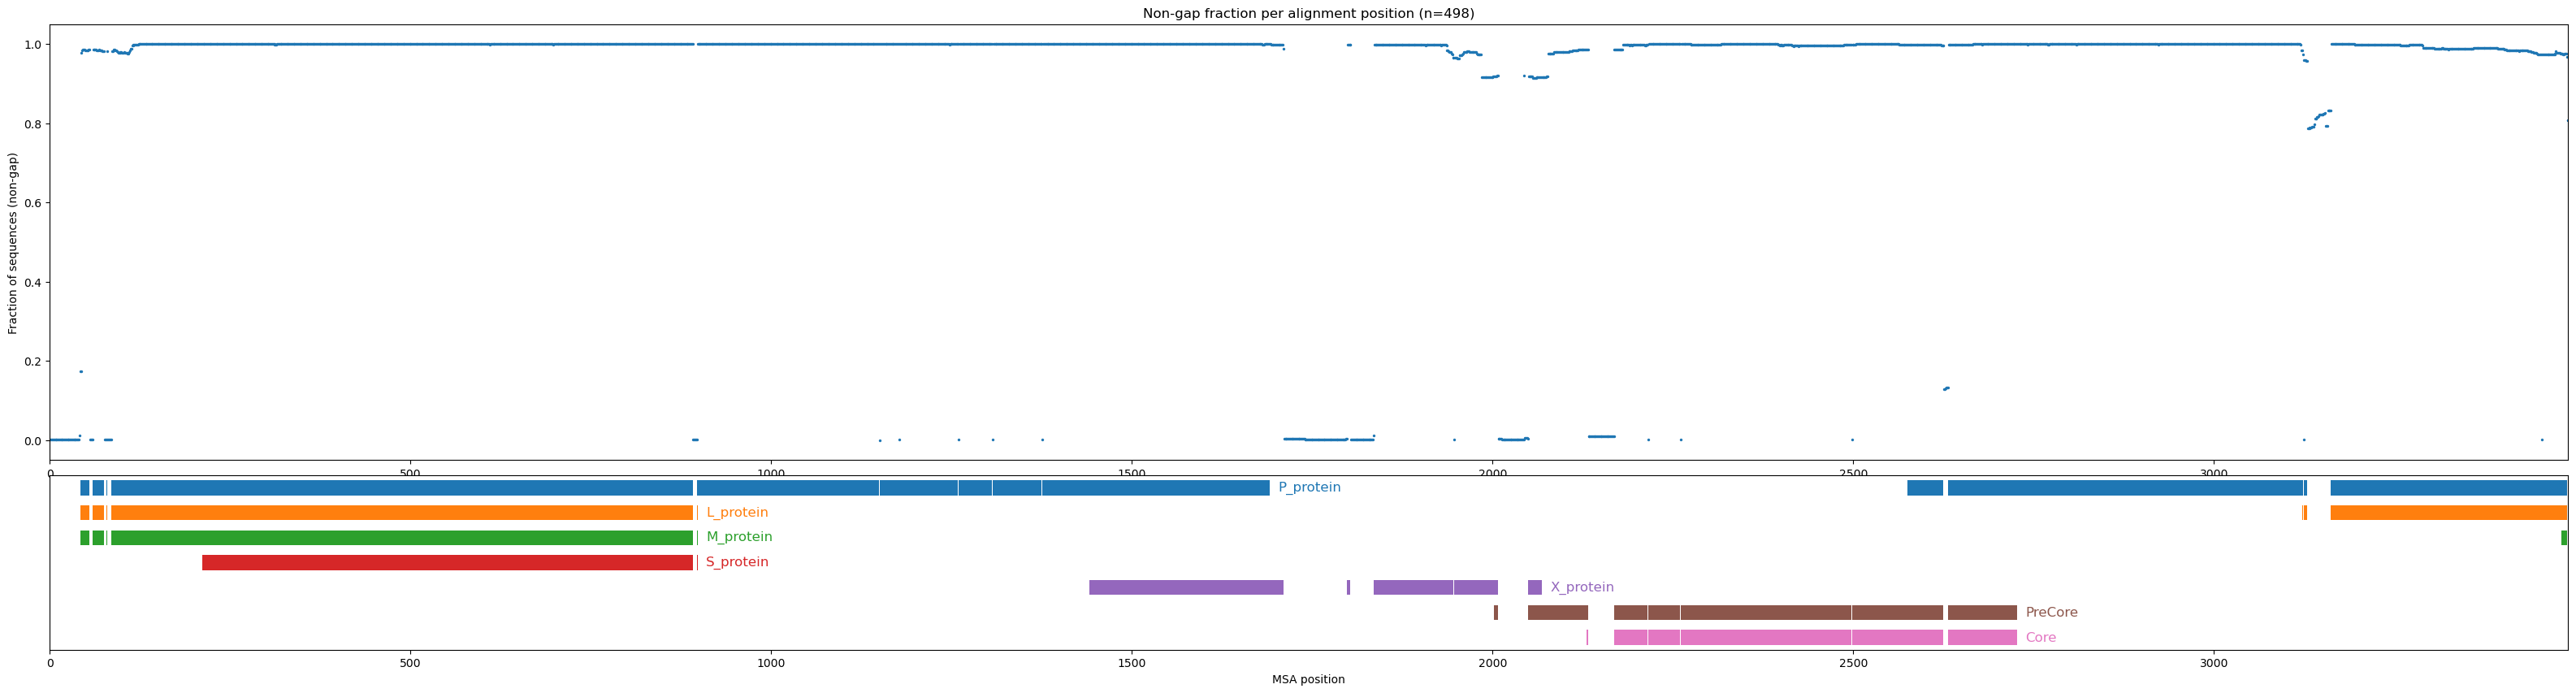

In [102]:
import numpy as np
import matplotlib.pyplot as plt

L = aln.get_alignment_length()
x = np.arange(1, len(rel) + 1)

fig = plt.figure(figsize=(40, 10))
gs = fig.add_gridspec(2, 1, height_ratios=[5, 2], hspace=0.05)
ax = fig.add_subplot(gs[0])

# --- upper plot ---
ax.scatter(x, rel, s=2)
ax.set_title(f"Non-gap fraction per alignment position (n={nseq})")
ax.set_ylabel("Fraction of sequences (non-gap)")
ax.set_xlim(0, L)

ax_track = add_annotation_track(fig, ax, gene_msa_blocks)

plt.show()


### <span style="color: green;"> indels per position - first approximation</span>


In [393]:
def plot_indel_with_genes(rel, aln, nseq, gene_msa_blocks=None, gene=None,
                          plot_ins=True, plot_del=True, figsize=(40, 10),
                          height_ratios=(6, 2), hspace=0.05):
    import numpy as np
    import matplotlib.pyplot as plt

    x = np.arange(1, len(rel) + 1)
    L = aln.get_alignment_length()
    rel_arr = np.asarray(rel)

    ins = np.where(rel_arr < 0.5, rel_arr, np.nan) if plot_ins else None
    del_ = np.where(rel_arr > 0.5, 1 - rel_arr, np.nan) if plot_del else None

    fig, (ax, ax_track) = plt.subplots(
        2, 1, sharex=True, figsize=figsize,
        gridspec_kw={"height_ratios": list(height_ratios), "hspace": hspace}
    )
    ax.tick_params(axis="x", labelbottom=True)

    if plot_ins:
        ax.scatter(x, ins, s=8, c="tab:blue",
                   label="insertions (<50% non-gap)")
    if plot_del:
        ax.scatter(x, del_, s=8, c="tab:orange",
                   label="deletions (gap fraction, >50% non-gap)")

    ax.set_ylabel("Percentage of sequences", fontsize=20)
    ax.set_title(f"Insertion/Deletion score per position (n={nseq})")
    ax.legend(markerscale=5, frameon=False, fontsize=20)

    if gene_msa_blocks is not None:
        add_annotation_track(fig, ax, gene_msa_blocks)

    # optional zoom to one gene span
    if gene is not None and gene_msa_blocks is not None:
        blocks = gene_msa_blocks[gene]
        xmin = min(s for s, e in blocks)
        xmax = max(e for s, e in blocks)
        pad = int(0.02 * (xmax - xmin + 1)) + 5
        ax.set_xlim(max(0, xmin - pad), min(L, xmax + pad))
    else:
        ax.set_xlim(0, L)

    plt.show()
    return fig, ax, ax_track


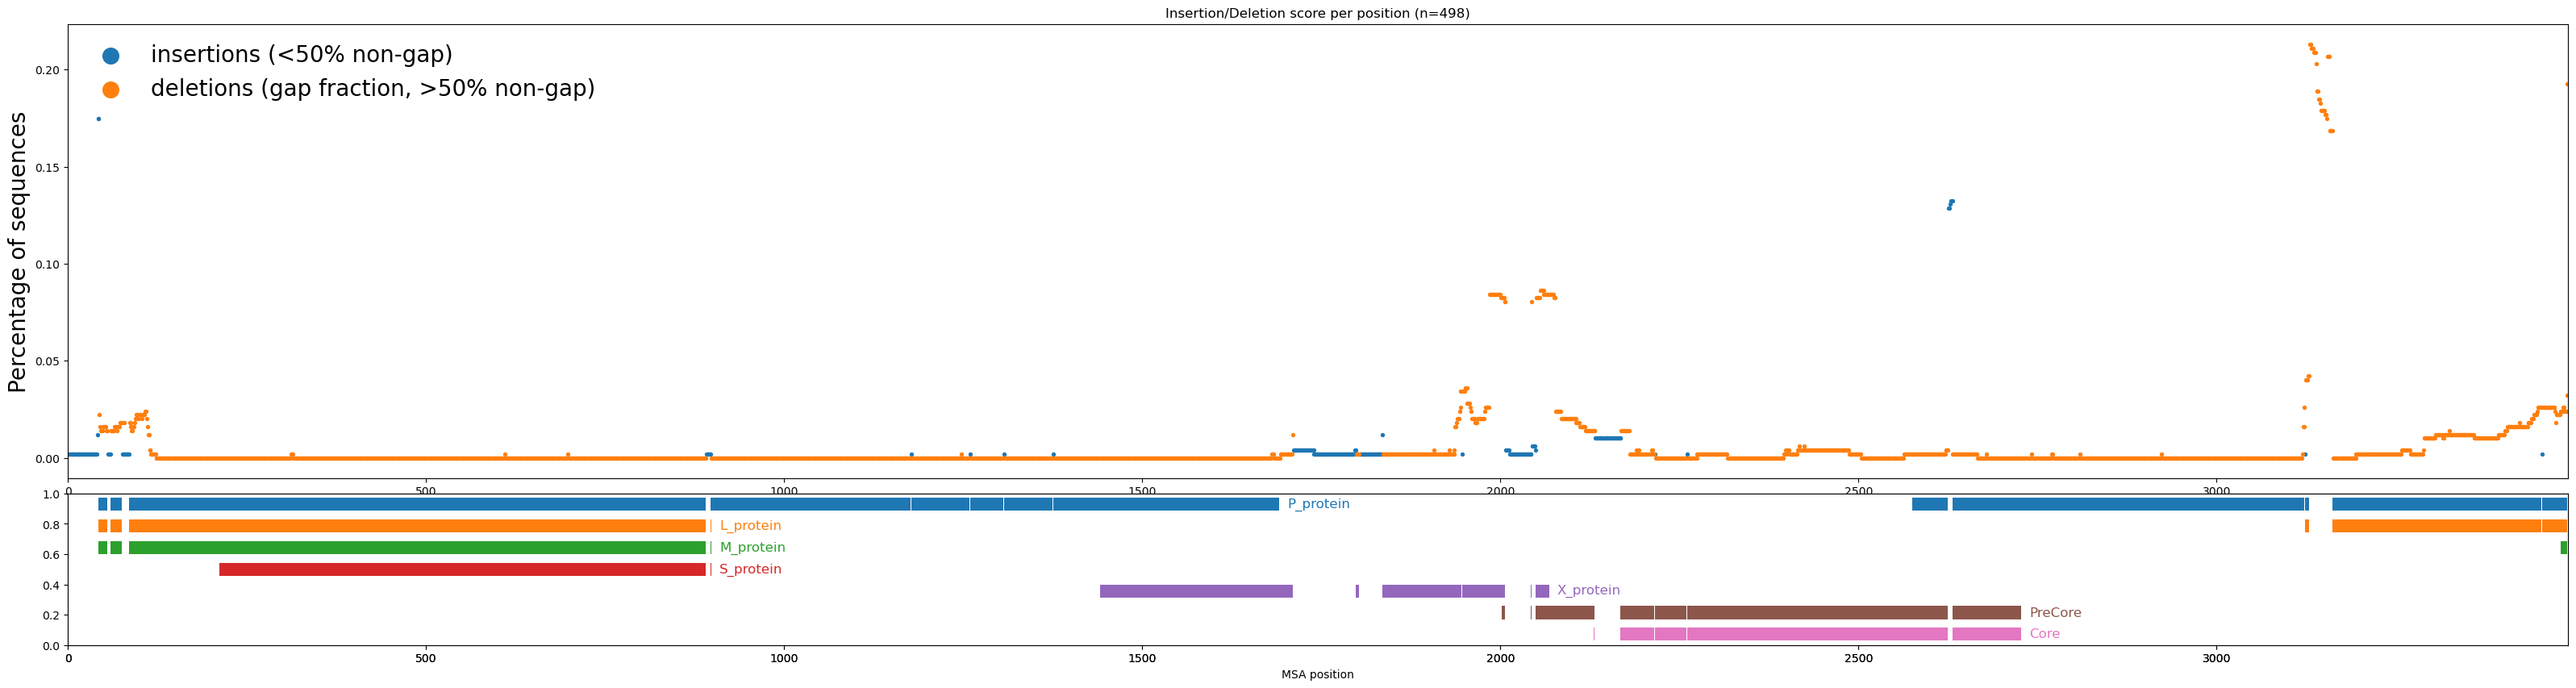

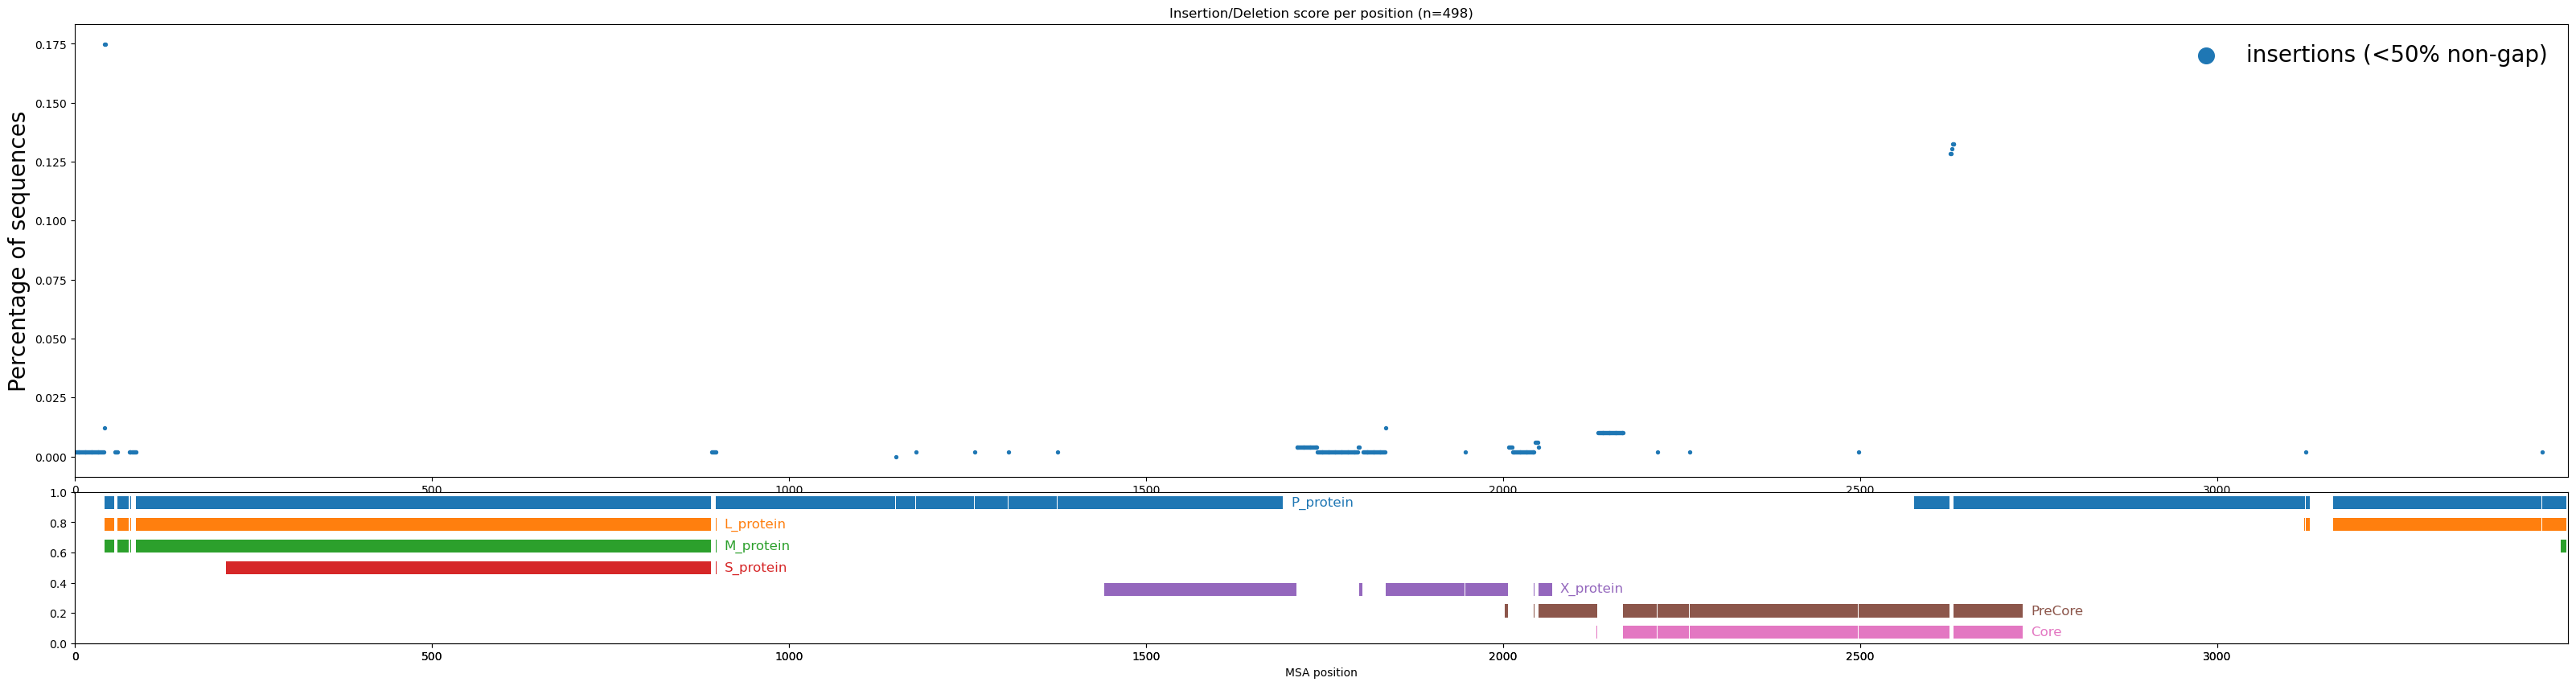

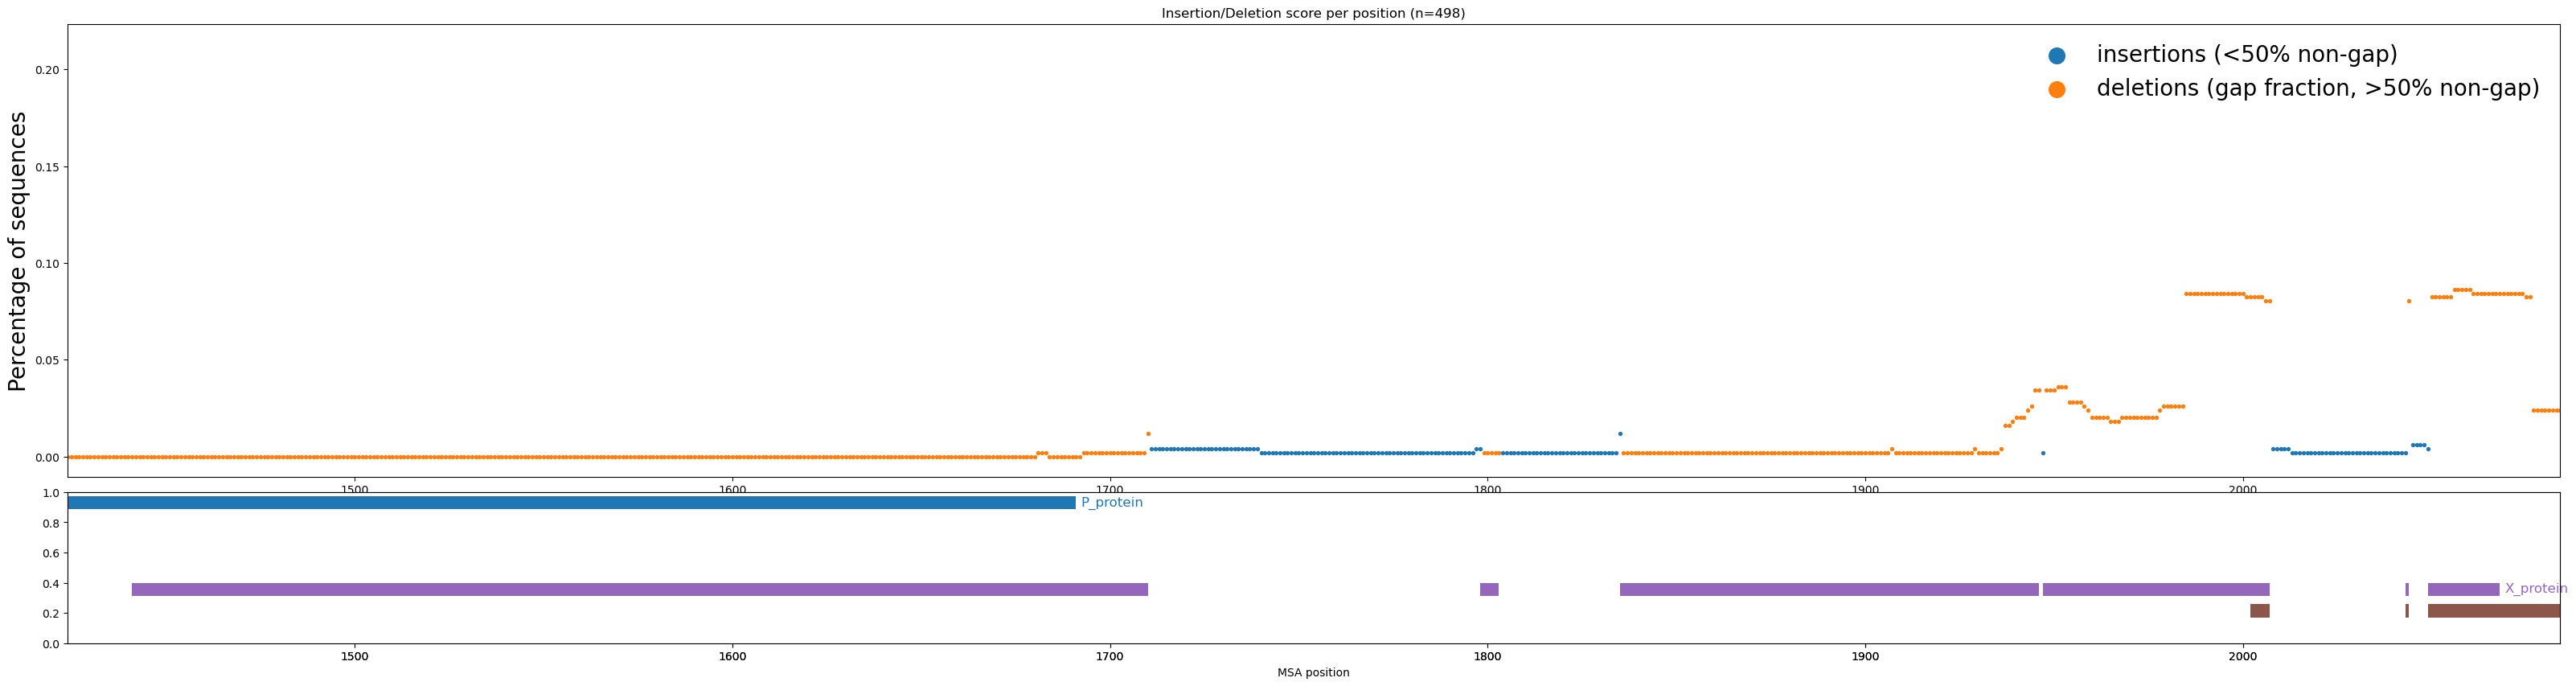

(<Figure size 4000x1000 with 3 Axes>,
 <Axes: title={'center': 'Insertion/Deletion score per position (n=498)'}, ylabel='Percentage of sequences'>,
 <Axes: >)

In [394]:
# both
plot_indel_with_genes(rel, aln, nseq, gene_msa_blocks)

# only deletions
plot_indel_with_genes(rel, aln, nseq, gene_msa_blocks, plot_del=False)

# zoom to one gene
plot_indel_with_genes(rel, aln, nseq, gene_msa_blocks, gene="X_protein")


# (Unique) Gaps and Breakpoints

## Define (Unique) gaps

### Functions

In [287]:
def gap_intervals_for_alignment(aln):
    """
    Returns: dict {seq_id: [(gap_start, gap_end), ...]}
    Positions are 1-based, inclusive.
    Circular merge: if a gap touches the end and start, it becomes one interval with gap_end < gap_start.
    """
    L = aln.get_alignment_length()
    gaps = {}

    for rec in aln:
        s = str(rec.seq)
        runs = []

        in_gap = False
        start = None
        gap_chars = {"-", "."}

        for i, c in enumerate(s):
            is_gap = c in gap_chars
            if is_gap and not in_gap:
                in_gap = True
                start = i
            elif not is_gap and in_gap:
                runs.append((start, i - 1))
                in_gap = False

        if in_gap:
            runs.append((start, L - 1))

        # merge end-gap with start-gap (circular)
        if runs and runs[0][0] == 0 and runs[-1][1] == L - 1 and len(runs) >= 2:
            merged = (runs[-1][0], runs[0][1])   # end < start indicates wrap
            runs = [merged] + runs[1:-1]

        # convert to 1-based inclusive
        gaps[rec.id] = [(a + 1, b + 1) for a, b in runs]

    return gaps



In [294]:
def print_gaps_at_pos(pos, obj, L):
    """
    Print all gaps covering alignment position `pos` (1-based).

    obj can be:
      - gap_info dict: {(s,e): {...}}
      - gaps_df DataFrame with columns s,e,type,nshare,support
    """
    def covers(g, pos):
        s, e = g
        if e >= s:
            return s <= pos <= e
        else:  # wrapped
            return pos >= s or pos <= e

    if isinstance(obj, dict):  # gap_info
        items = [((s, e), info) for (s, e), info in obj.items() if covers((s, e), pos)]
    else:  # DataFrame
        items = [((int(r.s), int(r.e)), r) for r in obj.itertuples(index=False)
                 if covers((int(r.s), int(r.e)), pos)]

    print(f"Position {pos}: {len(items)} gaps")
    for (s, e), info in items:
        t = info["type"] if isinstance(info, dict) else info.type
        n = info["nshare"] if isinstance(info, dict) else info.nshare
        sup = info["support"] if isinstance(info, dict) else info.support
        print(f"  {t.upper():7s} {s}-{e}  nshare={n} support={sup}")


In [279]:
def add_interval_to_pos_index(gaps_by_pos, gap, s, e, L):
    """Add a gap (s,e) to all positions it covers (0-based).
    Handles wrapped gaps by splitting into two segments."""
    def add(lo, hi):
        for p in range(lo, hi):
            gaps_by_pos[p].append(gap)

    if e >= s:
        add(s - 1, e)
    else:
        add(s - 1, L)
        add(0, e)

In [280]:
def build_gap_structures(unique_gaps, nseq, L):
    """Create gap_info (per-gap metadata) and gaps_by_pos (per-position lookup)."""
    gap_info = {}
    gaps_by_pos = [[] for _ in range(L)]

    for (s, e), nshare in unique_gaps.items():
        gtype = "ins" if nshare > nseq / 2 else "del"
        support = (nseq - nshare) if gtype == "ins" else nshare
        gap = (s, e)

        gap_info[gap] = {"type": gtype, "nshare": nshare, "support": support}
        add_interval_to_pos_index(gaps_by_pos, gap, s, e, L)

    return gap_info, gaps_by_pos

In [281]:
def gap_info_from_df(gaps_df):
    """Rebuild gap_info dict from gaps_df rows."""
    return {
        (int(r.s), int(r.e)): {
            "type": r.type,
            "nshare": int(r.nshare),
            "support": float(r.support),
        }
        for r in gaps_df.itertuples(index=False)
    }

In [283]:
import itertools
from collections import Counter
import numpy as np


def segs(g):
    s, e = g
    if e >= s:
        return [(s - 1, e)]          # 0-based, half-open [start, end)
    else:
        return [(s - 1, L), (0, e)]  # wrapped split

def overlap_len(A, B):
    tot = 0
    for a0, a1 in A:
        for b0, b1 in B:
            lo, hi = max(a0, b0), min(a1, b1)
            if hi > lo:
                tot += (hi - lo)
    return tot

def contains(A, B):
    # A contained in B iff every segment of A is fully covered by some segment of B
    for a0, a1 in A:
        if not any(b0 <= a0 and b1 >= a1 for b0, b1 in B):
            return False
    return True

def classify(g1, g2):
    A, B = segs(g1), segs(g2)
    ol = overlap_len(A, B)
    if ol == 0:
        return "disjoint"
    if g1 == g2:
        return "identical"
    a_in_b = contains(A, B)
    b_in_a = contains(B, A)
    if a_in_b or b_in_a:
        return "full"   # one fully contains the other (includes identical handled above)
    return "partial"    # overlaps but neither contains the other

def pair_stats(pairs):
    c = Counter(classify(g1, g2) for g1, g2 in pairs)
    total = sum(c.values())
    return {
        "total_pairs": total,
        "disjoint": c["disjoint"],
        "partial": c["partial"],
        "full": c["full"],
        "identical": c["identical"],
    }


def gap_len(g):
    return sum(b - a for a, b in segs(g))

def subtract_segs(B, A):
    # subtract segments A from segments B (both 0-based half-open), returns list of remaining segments
    out = []
    for b0, b1 in B:
        cur = [(b0, b1)]
        for a0, a1 in A:
            nxt = []
            for c0, c1 in cur:
                if a1 <= c0 or a0 >= c1:          # no overlap
                    nxt.append((c0, c1))
                else:
                    if c0 < a0:
                        nxt.append((c0, a0))
                    if a1 < c1:
                        nxt.append((a1, c1))
            cur = nxt
        out.extend(cur)
    return [(u0, u1) for u0, u1 in out if u1 > u0]


In [379]:
def apply_del_contained_by_ins_rewrite(gaps_df):
    """Drop deletions contained in insertions and add insertion remainders."""
    gaps_df_before = gaps_df.copy()

    ins_gaps = [(int(r.s), int(r.e)) for r in gaps_df[gaps_df.type == "ins"].itertuples(index=False)]
    del_gaps = [(int(r.s), int(r.e)) for r in gaps_df[gaps_df.type == "del"].itertuples(index=False)]

    rows_to_drop, rows_to_add = [], []

    for d in del_gaps:
        d_segs = segs(d)
        cand = [i for i in ins_gaps if contains(d_segs, segs(i))]
        if not cand:
            continue

        i_best = min(cand, key=gap_len)
        diff = subtract_segs(segs(i_best), d_segs)
        rows_to_drop.append(d)

        del_row = gaps_df[(gaps_df.type == "del") &
                        (gaps_df.s == d[0]) &
                        (gaps_df.e == d[1])].iloc[0]

        for u0, u1 in diff:
            rows_to_add.append({
                "s": u0 + 1,
                "e": u1,
                "type": "ins",
                "nshare": int(del_row.nshare),     # overwrite with deletion values
                "support": float(del_row.support), # overwrite with deletion values
            })

    if rows_to_drop:
        mask = False
        for s, e in rows_to_drop:
            mask |= ((gaps_df.type == "del") & (gaps_df.s == s) & (gaps_df.e == e))
        gaps_df = gaps_df.loc[~mask].copy()

    if rows_to_add:
        gaps_df = pd.concat([gaps_df, pd.DataFrame(rows_to_add)], ignore_index=True)

    return gaps_df_before, gaps_df


In [285]:
def mark_partial_ins_del_as_complex(gap_info):
    """Reassign gaps with partial ins/del overlap to type='complex'."""
    gaps_ins = [g for g, info in gap_info.items() if info["type"] == "ins"]
    gaps_del = [g for g, info in gap_info.items() if info["type"] == "del"]

    pairs_partial = []
    for g_ins in gaps_ins:
        A = segs(g_ins)
        for g_del in gaps_del:
            B = segs(g_del)
            if overlap_len(A, B) == 0:
                continue
            if not contains(A, B) and not contains(B, A):
                gap_info[g_ins]["type"] = "complex"
                gap_info[g_del]["type"] = "complex"
                pairs_partial.append((g_ins, g_del))

    return pairs_partial

In [286]:
def print_overlap_statistics(gap_info):

    gaps_ins = [g for g, info in gap_info.items() if info["type"] == "ins"]
    gaps_del = [g for g, info in gap_info.items() if info["type"] == "del"]


    stats_ins_ins = pair_stats(itertools.combinations(gaps_ins, 2))
    stats_del_del = pair_stats(itertools.combinations(gaps_del, 2))
    stats_ins_del = pair_stats(itertools.product(gaps_ins, gaps_del))

    print("ins/ins:", stats_ins_ins)
    print("del/del:", stats_del_del)
    print("ins/del:", stats_ins_del)




    pairs_del_contains_ins = []
    pairs_ins_contains_del = []
    pairs_partial = []

    for g_ins in gaps_ins:
        A = segs(g_ins)
        for g_del in gaps_del:
            B = segs(g_del)
            if overlap_len(A, B) == 0:
                continue

            ins_in_del = contains(A, B)
            del_in_ins = contains(B, A)

            if ins_in_del and not del_in_ins:
                pairs_del_contains_ins.append((g_del, g_ins))
            elif del_in_ins and not ins_in_del:
                pairs_ins_contains_del.append((g_ins, g_del))
            else:
                # includes "partial" and the rare "identical" case (shouldn't happen cross-type)
                pairs_partial.append((g_ins, g_del))

    print("DEL fully contains INS:")
    for g_del, g_ins in pairs_del_contains_ins:
        print(f"DEL {g_del[0]}-{g_del[1]}  contains  INS {g_ins[0]}-{g_ins[1]}")

    print("\nINS fully contains DEL:")
    for g_ins, g_del in pairs_ins_contains_del:
        print(f"INS {g_ins[0]}-{g_ins[1]}  contains  DEL {g_del[0]}-{g_del[1]}")

    print("\nPartial overlap (neither contains the other):")
    for g_ins, g_del in pairs_partial:
        print(f"INS {g_ins[0]}-{g_ins[1]}  overlaps  DEL {g_del[0]}-{g_del[1]}")


def print_change(gaps_df_before,gaps_df):
    
    before_keys = set(map(tuple, gaps_df_before[["s", "e", "type"]].to_numpy()))
    after_keys  = set(map(tuple, gaps_df[["s", "e", "type"]].to_numpy()))

    dropped = before_keys - after_keys
    added   = after_keys - before_keys

    print(f"Dropped: {len(dropped)} rows")
    for s, e, t in sorted(dropped):
        row = gaps_df_before[(gaps_df_before.s == s) & (gaps_df_before.e == e) & (gaps_df_before.type == t)].iloc[0]
        print(f"  - {t} {s}-{e}  nshare={int(row.nshare)} support={float(row.support)}")

    print(f"Added: {len(added)} rows")
    for s, e, t in sorted(added):
        row = gaps_df[(gaps_df.s == s) & (gaps_df.e == e) & (gaps_df.type == t)].iloc[0]
        print(f"  + {t} {s}-{e}  nshare={int(row.nshare)} support={float(row.support)}")

### Pipeline

Extract all gaps from MSA


In [ ]:
gaps_by_seq = gap_intervals_for_alignment(aln)


In [290]:
gaps_by_seq

{'NC_003977': [(3490, 41),
  (56, 59),
  (76, 78),
  (80, 85),
  (892, 897),
  (1150, 1150),
  (1178, 1178),
  (1260, 1260),
  (1307, 1307),
  (1376, 1376),
  (1711, 1798),
  (1804, 1835),
  (1947, 1947),
  (2008, 2043),
  (2045, 2049),
  (2133, 2168),
  (2216, 2216),
  (2261, 2261),
  (2498, 2498),
  (2626, 2631),
  (3124, 3124),
  (3130, 3162),
  (3455, 3455)],
 'PQ256967': [(3490, 41),
  (56, 59),
  (76, 78),
  (80, 85),
  (892, 897),
  (1150, 1150),
  (1178, 1178),
  (1260, 1260),
  (1307, 1307),
  (1376, 1376),
  (1711, 1798),
  (1804, 1835),
  (1947, 1947),
  (2008, 2043),
  (2045, 2049),
  (2133, 2168),
  (2216, 2216),
  (2261, 2261),
  (2498, 2498),
  (2626, 2631),
  (3124, 3124),
  (3130, 3162),
  (3455, 3455)],
 'PQ256969': [(3490, 41),
  (56, 59),
  (76, 78),
  (80, 85),
  (892, 897),
  (1150, 1150),
  (1178, 1178),
  (1260, 1260),
  (1307, 1307),
  (1376, 1376),
  (1711, 1798),
  (1804, 1835),
  (1947, 1947),
  (2008, 2043),
  (2045, 2049),
  (2133, 2168),
  (2216, 2216),
 

Filter to only have unique gaps (individual events) with counts of how many sequences share event

In [292]:
from collections import Counter

# gaps_by_seq: {seq_id: [(start,end), ...]} from before
unique_gaps = Counter()

for intervals in gaps_by_seq.values():
    # avoid double-counting same gap within one sequence
    for gap in set(intervals):
        unique_gaps[gap] += 1
unique_gaps = dict(unique_gaps)


In [293]:
unique_gaps

{(2133, 2168): 486,
 (3130, 3162): 84,
 (1150, 1150): 498,
 (1260, 1260): 497,
 (2626, 2631): 431,
 (2261, 2261): 497,
 (3124, 3124): 477,
 (1178, 1178): 497,
 (3455, 3455): 484,
 (892, 897): 497,
 (80, 85): 488,
 (1376, 1376): 497,
 (3490, 41): 79,
 (76, 78): 488,
 (1307, 1307): 497,
 (2216, 2216): 496,
 (1804, 1835): 491,
 (2008, 2043): 456,
 (1947, 1947): 480,
 (56, 59): 490,
 (2045, 2049): 455,
 (1711, 1798): 490,
 (2498, 2498): 496,
 (1985, 2076): 29,
 (3121, 3139): 6,
 (1945, 1953): 4,
 (1943, 1964): 1,
 (3123, 3138): 3,
 (3259, 3270): 1,
 (3475, 41): 2,
 (1, 43): 397,
 (1954, 2105): 1,
 (3489, 40): 4,
 (3155, 3157): 17,
 (3480, 53): 1,
 (3403, 43): 1,
 (2049, 2118): 1,
 (1944, 2000): 1,
 (1937, 2180): 6,
 (2626, 2628): 1,
 (3435, 44): 1,
 (100, 102): 1,
 (95, 109): 1,
 (3195, 3315): 1,
 (1951, 1959): 1,
 (93, 113): 2,
 (1, 40): 1,
 (65, 67): 1,
 (108, 110): 1,
 (2396, 2398): 1,
 (3121, 3154): 1,
 (73, 87): 1,
 (1804, 1834): 5,
 (1710, 1798): 5,
 (1, 44): 2,
 (3124, 3145): 2,
 (3

Label gaps as insertions or deletions

In [380]:
import pandas as pd

gap_info, gaps_by_pos = build_gap_structures(unique_gaps, nseq, L)
gaps_df = pd.DataFrame([{"s": s, "e": e, **info} for (s, e), info in gap_info.items()])

In [381]:
gaps_df

,s,e,type,nshare,support
0,2133,2168,ins,486,12
1,3130,3162,del,84,84
2,1150,1150,ins,498,0
3,1260,1260,ins,497,1
4,2626,2631,ins,431,67
...,...,...,...,...,...
117,3318,3359,del,1,1
118,1968,2216,del,1,1
119,2742,2742,del,1,1
120,91,111,del,1,1


Correct lables for probable overlapping insertion events. Introduce "complex" label for unclear partially overlapping events.

In [382]:
before, gaps_df = apply_del_contained_by_ins_rewrite(gaps_df)
print_change(before, gaps_df)

gap_info = gap_info_from_df(gaps_df)

gaps_df_before = gaps_df.copy()
pairs_partial = mark_partial_ins_del_as_complex(gap_info)

gaps_df = pd.DataFrame([{"s": s, "e": e, **info} for (s, e), info in gap_info.items()])
print_change(gaps_df_before, gaps_df)


Dropped: 5 rows
  - del 1-40  nshare=1 support=1.0
  - del 1740-1796  nshare=1 support=1.0
  - del 1804-1834  nshare=5 support=5.0
  - del 2013-2043  nshare=1 support=1.0
  - del 2626-2628  nshare=1 support=1.0
Added: 6 rows
  + ins 41-43  nshare=1 support=1.0
  + ins 1711-1739  nshare=1 support=1.0
  + ins 1797-1798  nshare=1 support=1.0
  + ins 1835-1835  nshare=5 support=5.0
  + ins 2008-2012  nshare=1 support=1.0
  + ins 2629-2631  nshare=1 support=1.0
Dropped: 9 rows
  - ins 1-43  nshare=397 support=101.0
  - ins 41-43  nshare=1 support=1.0
  - ins 2045-2049  nshare=455 support=43.0
  - del 2049-2118  nshare=1 support=1.0
  - del 2622-2627  nshare=1 support=1.0
  - ins 2626-2631  nshare=431 support=67.0
  - del 3475-41  nshare=2 support=2.0
  - del 3489-40  nshare=4 support=4.0
  - del 3490-41  nshare=79 support=79.0
Added: 9 rows
  + complex 1-43  nshare=397 support=101.0
  + complex 41-43  nshare=1 support=1.0
  + complex 2045-2049  nshare=455 support=43.0
  + complex 2049-2118 

### Plotting

In [352]:
gaps_df[gaps_df["support"]>100]

,s,e,type,nshare,support
30,1,43,complex,397,101.0
118,41,43,complex,397,101.0


In [395]:
def plot_indel_tracks(ins_y, del_y, complex_y, aln, nseq,
                      gene_msa_blocks=None, gene=None,
                      plot_ins=True, plot_del=True, plot_complex=True,
                      figsize=(40, 10), height_ratios=(6, 2), hspace=0.05):

    L = aln.get_alignment_length()
    x = np.arange(1, L + 1)

    fig, (ax, ax_track) = plt.subplots(
        2, 1, sharex=True, figsize=figsize,
        gridspec_kw={"height_ratios": list(height_ratios), "hspace": hspace}
    )
    ax.tick_params(axis="x", labelbottom=True)

    if plot_ins:
        m = ~np.isnan(ins_y)
        ax.scatter(x[m], ins_y[m], s=8, marker="o", label="insertions (heavily overestimated)")
    if plot_del:
        m = ~np.isnan(del_y)
        ax.scatter(x[m], del_y[m], s=8, marker="o", label="deletions")
    if plot_complex:
        m = ~np.isnan(complex_y)
        ax.scatter(x[m], complex_y[m], s=8, marker="o", label="complex (heavily overestimated)")
        
    ymax = np.nanmax(np.r_[ins_y, del_y, complex_y])
    if np.isfinite(ymax):
        ax.set_ylim(0, ymax * 1.05)
    ax.set_ylabel("Fraction of sequences", fontsize=20)
    ax.set_title(f"Indel calls per position (n={nseq})")
    ax.legend(markerscale=5, frameon=False, fontsize=20)

    if gene_msa_blocks is not None:
        add_annotation_track(fig, ax, gene_msa_blocks)

    if gene is not None and gene_msa_blocks is not None:
        blocks = gene_msa_blocks[gene]
        xmin = min(s for s, e in blocks)
        xmax = max(e for s, e in blocks)
        pad = int(0.02 * (xmax - xmin + 1)) + 5
        ax.set_xlim(max(0, xmin - pad), min(L, xmax + pad))
    else:
        ax.set_xlim(0, L)
    

    plt.show()
    return fig, ax, ax_track


In [396]:
def compute_indel_tracks(gaps_df, aln, nseq):
    L = aln.get_alignment_length()

    ins_y = np.full(L, np.nan)
    del_y = np.full(L, np.nan)
    complex_y = np.full(L, np.nan)

    def segs_row(s, e):
        if e >= s:
            return [(s - 1, e)]
        return [(s - 1, L), (0, e)]

    for r in gaps_df.itertuples(index=False):
        s, e = int(r.s), int(r.e)

        # fraction logic consistent with earlier code
        frac = r.support / nseq

        for lo, hi in segs_row(s, e):
            if r.type == "ins":
                cur = np.nan_to_num(ins_y[lo:hi], nan=0.0)
                ins_y[lo:hi] = cur + frac
            elif r.type == "del":
                cur = np.nan_to_num(del_y[lo:hi], nan=0.0)
                del_y[lo:hi] = cur + frac
            elif r.type == "complex":
                cur = complex_y[lo:hi]
                complex_y[lo:hi] = np.nanmax(
                    np.c_[np.nan_to_num(cur, nan=0.0), np.full(hi - lo, frac)],
                    axis=1
                )


    return ins_y, del_y, complex_y


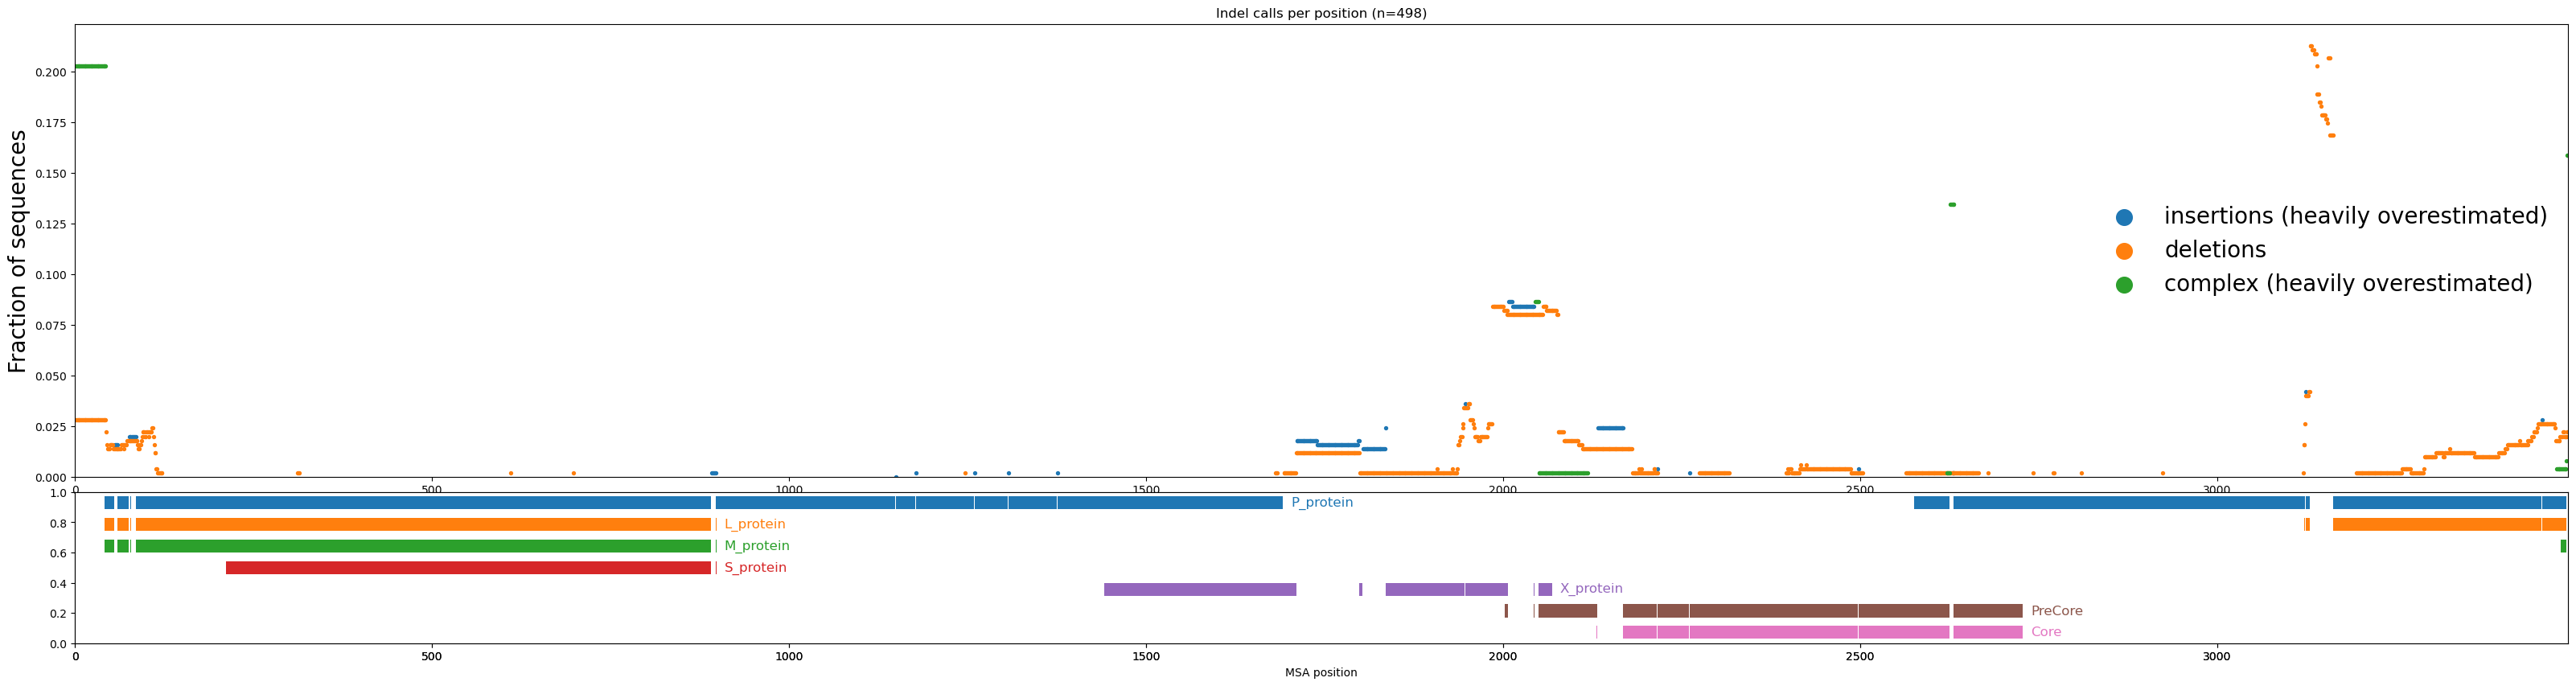

(<Figure size 4000x1000 with 3 Axes>,
 <Axes: title={'center': 'Indel calls per position (n=498)'}, ylabel='Fraction of sequences'>,
 <Axes: >)

In [397]:
ins_y, del_y, complex_y = compute_indel_tracks(gaps_df, aln, nseq)
plot_indel_tracks(ins_y, del_y, complex_y, aln, nseq, gene_msa_blocks)


### All gaps that cover a given position

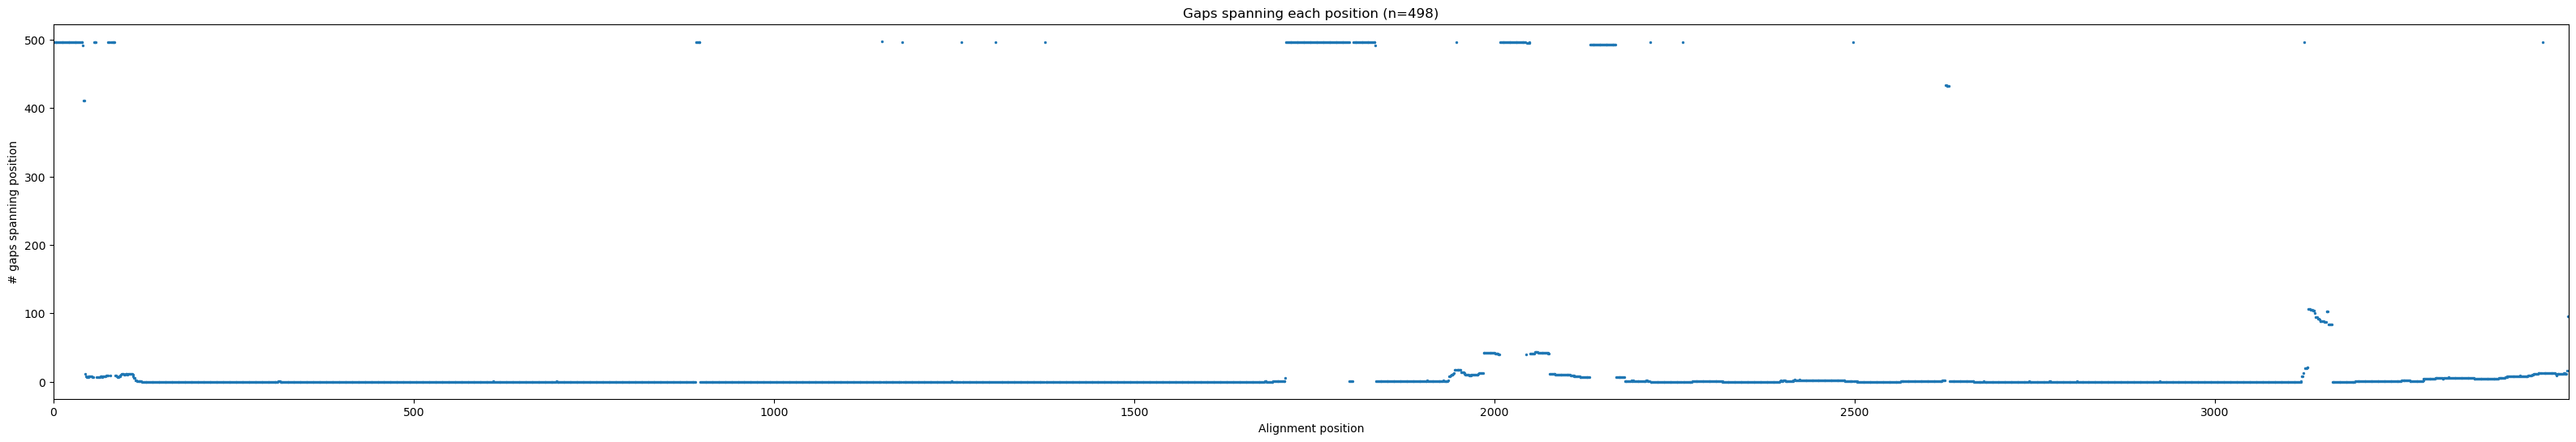

In [190]:
L = aln.get_alignment_length()
gap_counts = np.zeros(L, dtype=int)

for intervals in gaps_by_seq.values():
    for s, e in intervals:
        if e >= s:
            gap_counts[s-1:e] += 1
        else:
            # wrapped gap: s..L and 1..e
            gap_counts[s-1:L] += 1
            gap_counts[0:e] += 1

x = np.arange(1, L + 1)
plt.figure(figsize=(40, 6))
plt.scatter(x, gap_counts, s=2)
plt.xlim(0, L)
plt.xlabel("Alignment position")
plt.ylabel("# gaps spanning position")
plt.title(f"Gaps spanning each position (n={len(gaps_by_seq)})")
plt.show()


### Unique gaps per position

In [276]:
import matplotlib.colors as mcolors
import numpy as np

def truncate_cmap(cmap, minval=0.0, maxval=0.85, n=256):
    return mcolors.LinearSegmentedColormap.from_list(
        f"trunc_{cmap.name}",
        cmap(np.linspace(minval, maxval, n))
    )

cmap = truncate_cmap(plt.cm.viridis, 0.0, 0.85)


<Figure size 4000x600 with 0 Axes>

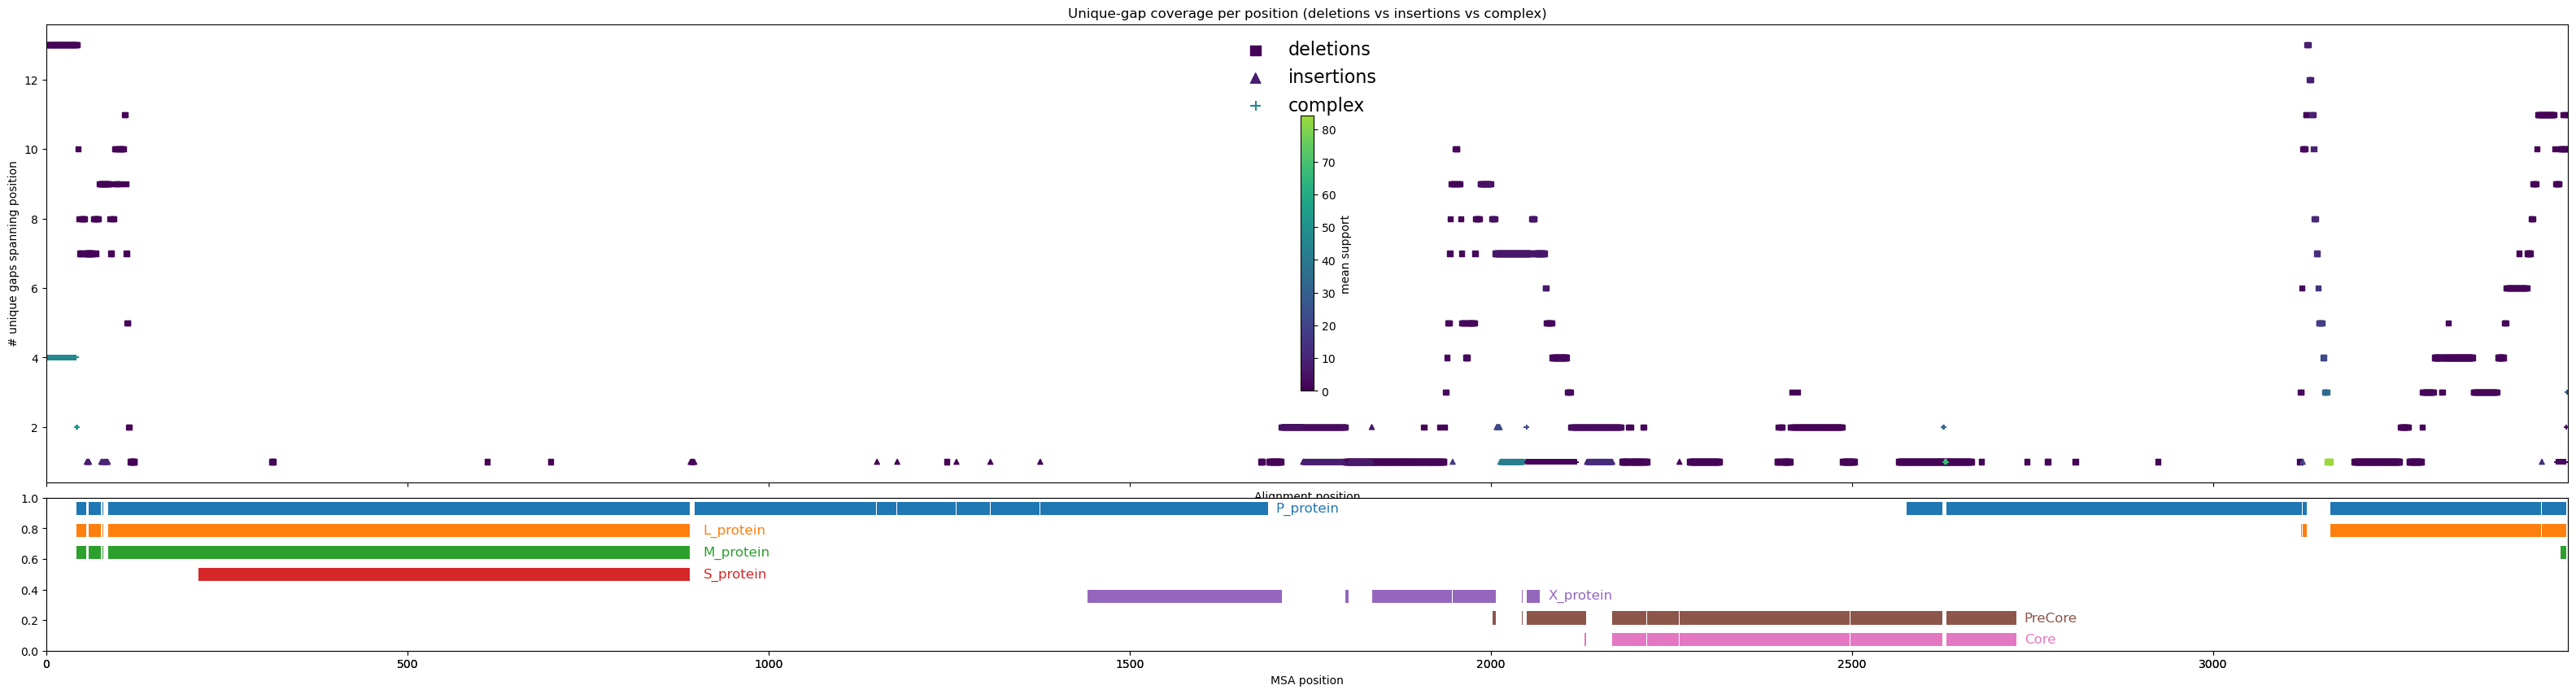

In [416]:
L = aln.get_alignment_length()
nseq = len(aln)  # total sequences

# per-position counts
del_count = np.zeros(L, dtype=int)
ins_count = np.zeros(L, dtype=int)

# per-position support sums (use the already-refined `support` in gaps_df)
del_support_sum = np.zeros(L, dtype=float)
ins_support_sum = np.zeros(L, dtype=float)

complex_count = np.zeros(L, dtype=int)
complex_support_sum = np.zeros(L, dtype=float)



def add_interval(a_count, a_sum, lo, hi, support):
    a_count[lo:hi] += 1
    a_sum[lo:hi] += support

# iterate over refined gaps (same logic: ins vs del, wrapped handling)
for r in gaps_df.itertuples(index=False):
    s, e = int(r.s), int(r.e)
    gtype = r.type
    support = float(r.support)

    if e >= s:
        lo, hi = s - 1, e
        if gtype == "ins":
            add_interval(ins_count, ins_support_sum, lo, hi, support)
        elif gtype == "del":
            add_interval(del_count, del_support_sum, lo, hi, support)
        else:
            add_interval(complex_count, complex_support_sum, lo, hi, support)
    else:
        # wrapped gap: s..L and 1..e
        if gtype == "ins":
            add_interval(ins_count, ins_support_sum, s - 1, L, support)
            add_interval(ins_count, ins_support_sum, 0, e, support)
        elif gtype == "del":
            add_interval(del_count, del_support_sum, s - 1, L, support)
            add_interval(del_count, del_support_sum, 0, e, support)
        else:
            add_interval(complex_count, complex_support_sum, s - 1, L, support)
            add_interval(complex_count, complex_support_sum, 0, e, support)

del_avg_support = np.divide(
    del_support_sum, del_count,
    out=np.full(L, np.nan),
    where=del_count > 0
)
ins_avg_support = np.divide(
    ins_support_sum, ins_count,
    out=np.full(L, np.nan),
    where=ins_count > 0
)
complex_avg_support = np.divide(
    complex_support_sum, complex_count,
    out=np.full(L, np.nan),
    where=complex_count > 0
)


# shared color scale across both
vmax = np.nanmax(np.r_[del_avg_support, ins_avg_support, complex_avg_support])
norm = plt.Normalize(vmin=0, vmax=vmax)
plt.figure(figsize=(40, 6))

x = np.arange(1, L + 1)
m_del = del_count > 0
m_ins = ins_count > 0
m_complex = complex_count > 0


fig, (ax, ax_track) = plt.subplots(
    2, 1, sharex=True, figsize=(40, 10),
    gridspec_kw={"height_ratios": [6, 2], "hspace": 0.05}
)


ax.scatter(x[m_del], del_count[m_del], s=20, marker="s",
             c=del_avg_support[m_del], cmap=cmap, norm=norm, label="deletions")

ax.scatter(x[m_ins], ins_count[m_ins], s=20, marker="^",
            c=ins_avg_support[m_ins], cmap=cmap, norm=norm, label="insertions")


# add complex scatter (choose a marker you like)
ax.scatter(x[m_complex], complex_count[m_complex], s=20, marker="+",
            c=complex_avg_support[m_complex], cmap=cmap, norm=norm, label="complex")




ax.set_xlim(0, L)
ax.set_xlabel("Alignment position")
ax.set_ylabel("# unique gaps spanning position")
ax.set_title("Unique-gap coverage per position (deletions vs insertions vs complex)")
ax.legend(frameon=False, fontsize=16, markerscale=2)

add_annotation_track(fig, ax, gene_msa_blocks)
ax.set_xlim(0, L)
ax_track.set_xlim(0, L)


sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

cax = inset_axes(
    ax,
    width="0.5%",        # width relative to ax
    height="60%",      # height relative to ax
    loc="center",
    borderpad=1
)

fig.colorbar(sm, cax=cax, label="mean support")

plt.show()


#### Example

In [417]:
### Example

pos = 1  # 1-based alignment position

gaps_at_pos = [
    ((s, e), nshare)
    for (s, e), nshare in unique_gaps.items()
    if (s <= e and s <= pos <= e) or
       (s > e and (pos >= s or pos <= e))  # wrapped gap
]

for (s, e), nshare in gaps_at_pos:
    print(f"gap {s}-{e}, shared by {nshare} sequences")


gap 3490-41, shared by 79 sequences
gap 3475-41, shared by 2 sequences
gap 1-43, shared by 397 sequences
gap 3489-40, shared by 4 sequences
gap 3480-53, shared by 1 sequences
gap 3403-43, shared by 1 sequences
gap 3435-44, shared by 1 sequences
gap 1-40, shared by 1 sequences
gap 1-44, shared by 2 sequences
gap 1-110, shared by 1 sequences
gap 3449-43, shared by 1 sequences
gap 1-88, shared by 1 sequences
gap 3406-115, shared by 1 sequences
gap 3484-45, shared by 1 sequences
gap 3440-92, shared by 1 sequences
gap 3306-43, shared by 1 sequences
gap 3443-113, shared by 1 sequences
gap 3490-122, shared by 1 sequences


### Gap boundaries ("Breakpoints?") per position

In [446]:
L = aln.get_alignment_length()

xs, cs, lens = [], [], []
events_per_pos = np.zeros(L, dtype=int)

def gap_len(s, e, L):
    # 1-based inclusive, wrapped allowed
    return (e - s + 1) if e >= s else (L - s + 1) + e

for r in gaps_df.itertuples(index=False):
    s, e = int(r.s), int(r.e)
    sup = float(r.support)
    glen = gap_len(s, e, L)

    if glen == 1:
        # point mutation / length-1 event: count ONCE at that position
        events_per_pos[s - 1] += 1
        xs.append(s)
        cs.append(sup)
        lens.append(glen)
    else:
        # gap: boundary events (start + end)
        events_per_pos[s - 1] += 1
        xs.append(s)
        cs.append(sup)
        lens.append(glen)

        events_per_pos[e - 1] += 1
        xs.append(e)
        cs.append(sup)
        lens.append(glen)

xs = np.asarray(xs)
cs = np.asarray(cs)
lens = np.asarray(lens)
ys = events_per_pos[xs - 1]



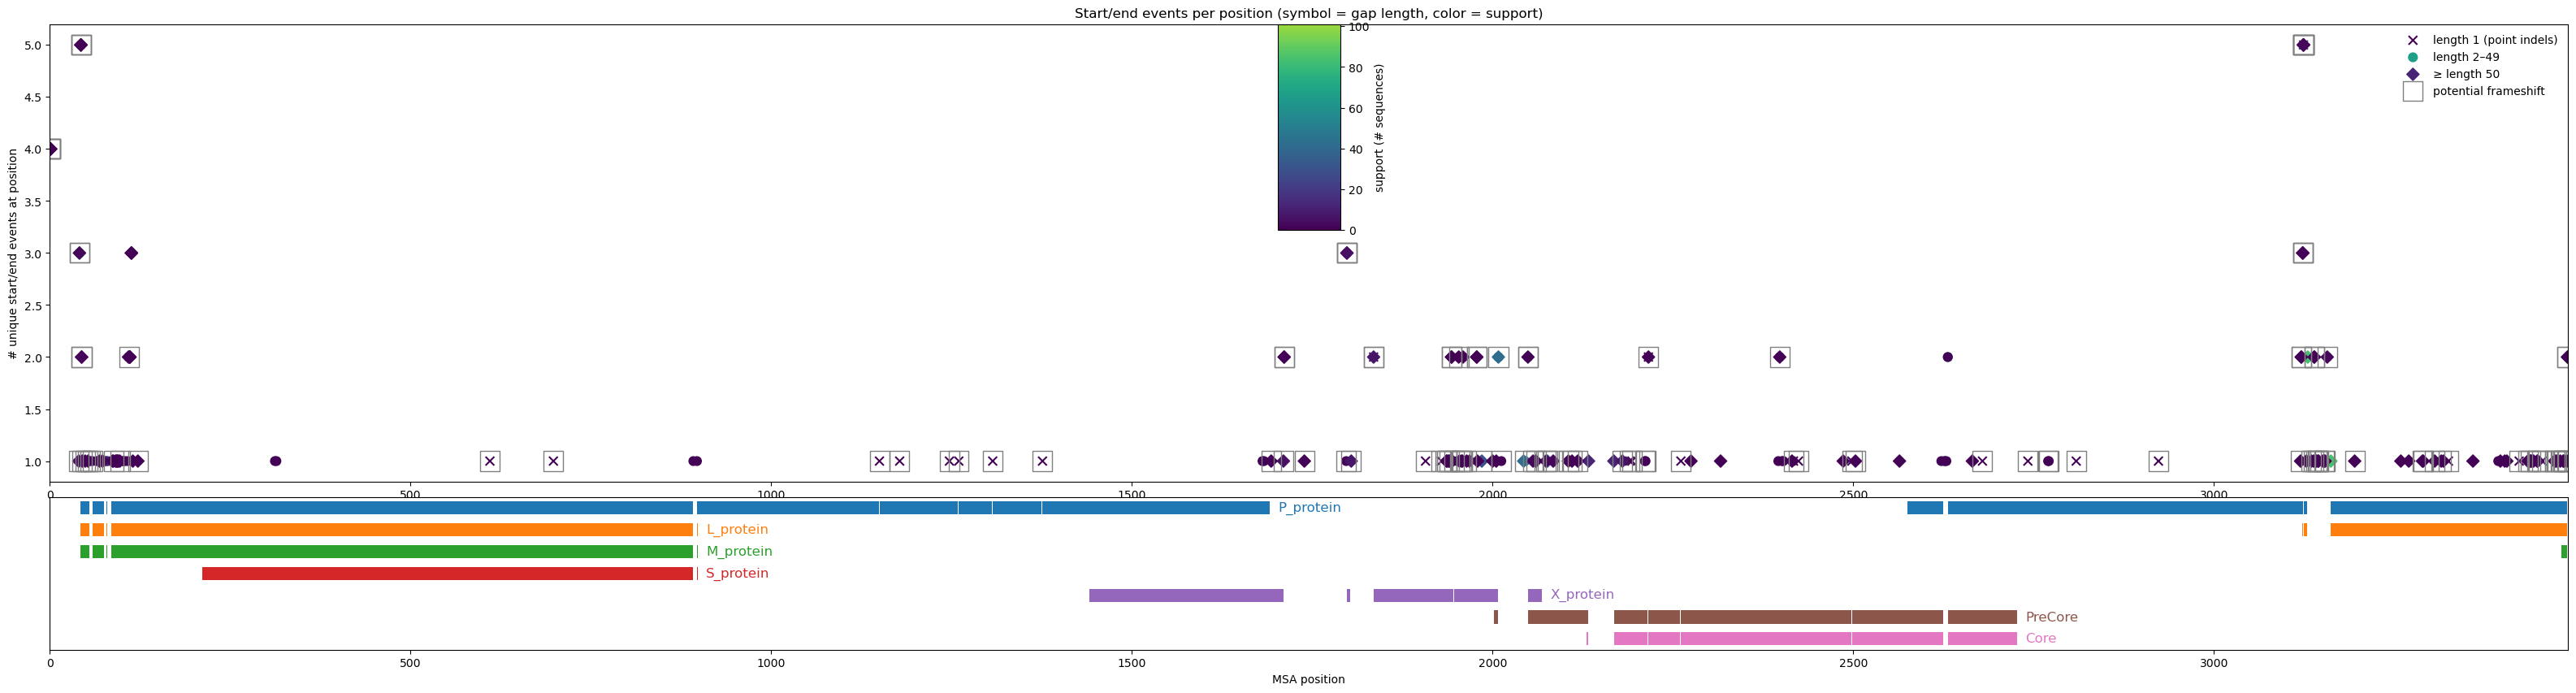

In [ ]:
fig = plt.figure(figsize=(40, 10))
gs = fig.add_gridspec(2, 1, height_ratios=[6, 2], hspace=0.05)
ax = fig.add_subplot(gs[0, 0])

# symbol meaning: by GAP LENGTH
m_pt   = lens == 1
m_lt10 = (lens > 1) & (lens < 10)
m_gt10 = lens >= 10   # change to (lens > 10) if you really want strict >10

norm = plt.Normalize(vmin=np.min(cs), vmax=np.max(cs))

sc = ax.scatter(xs[m_pt], ys[m_pt], s=60, c=cs[m_pt], marker="x", cmap=cmap,
                label="length 1 (point indels)", norm=norm)
ax.scatter(xs[m_lt10], ys[m_lt10], s=60, c=cs[m_lt10], marker="o", cmap=cmap,
           label="length 2–49", norm=norm)
ax.scatter(xs[m_gt10], ys[m_gt10], s=60, c=cs[m_gt10], marker="D", cmap=cmap,
           label="≥ length 50", norm=norm)

ax.set_xlim(0, L)
ax.set_ylabel("# unique start/end events at position")
ax.set_title("Start/end events per position (symbol = gap length, color = support)")
ax.legend(frameon=False)



# compute which plotted events come from gaps with length % 3 != 0
not3 = (lens % 3) != 0

# overlay: same x/y points, but hollow squares as "boxes"
ax.scatter(
    xs[not3], ys[not3],
    s=300, marker="s",
    facecolors="none", edgecolors="grey", linewidths=1,
    label="potential frameshift"
)

# if you want it in the legend (and keep order), call legend again:
ax.legend(frameon=False)

# annotation track
add_annotation_track(fig, ax, gene_msa_blocks)



# colorbar centered inside top plot
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
cax = inset_axes(ax, width="2.5%", height="45%", loc="upper center", borderpad=0)
fig.colorbar(sc, cax=cax, label="support (# sequences)")

plt.show()



# Frameshifts

In [452]:
L = aln.get_alignment_length()

def gap_length(s, e, L):
    return (e - s + 1) if e >= s else (L - s + 1) + e

# add length + divisibility
gaps_df["length"] = [
    gap_length(int(r.s), int(r.e), L)
    for r in gaps_df.itertuples(index=False)
]
gaps_df["div3"] = (gaps_df["length"] % 3) == 0

# overall stats split by type
stats = (
    gaps_df
    .groupby("type")["div3"]
    .value_counts()
    .unstack(fill_value=0)
    .rename(columns={True: "divisible_by_3", False: "not_divisible_by_3"})
)

# add totals and fractions
stats["total"] = stats.sum(axis=1)
stats["fraction_div3"] = stats["divisible_by_3"] / stats["total"]

print(stats)


div3     not_divisible_by_3  divisible_by_3  total  fraction_div3
type                                                             
complex                   6               3      9       0.333333
del                      55              35     90       0.388889
ins                      18               6     24       0.250000


In [458]:
L = aln.get_alignment_length()

def gap_length(s, e, L):
    return (e - s + 1) if e >= s else (L - s + 1) + e

seqs_with_frameshift_gaps = 0
total_seqs = len(gaps_by_seq)

for seq_id, gaps in gaps_by_seq.items():
    # check if this sequence has ANY gap not divisible by 3
    if any(gap_length(s, e, L) % 3 != 0 for s, e in gaps):
        seqs_with_frameshift_gaps += 1

print(f"{seqs_with_frameshift_gaps} / {total_seqs} sequences "
      f"({seqs_with_frameshift_gaps / total_seqs:.2%}) "
      f"contain at least one gap not divisible by 3")


498 / 498 sequences (100.00%) contain at least one gap not divisible by 3


In [459]:
L = aln.get_alignment_length()

def gap_length(s, e, L):
    return (e - s + 1) if e >= s else (L - s + 1) + e

seqs_with_frameshift_gaps = 0
total_seqs = len(gaps_by_seq)

for seq_id, gaps in gaps_by_seq.items():
    # only consider non-wrapped gaps (do not span origin): e >= s
    non_wrapped = [(s, e) for (s, e) in gaps if e >= s]

    if any(gap_length(s, e, L) % 3 != 0 for s, e in non_wrapped):
        seqs_with_frameshift_gaps += 1

print(f"{seqs_with_frameshift_gaps} / {total_seqs} sequences "
      f"({seqs_with_frameshift_gaps / total_seqs:.2%}) "
      f"contain at least one NON-wrapped gap not divisible by 3")


498 / 498 sequences (100.00%) contain at least one NON-wrapped gap not divisible by 3


In [ ]:
^^^Well yeah thats cause one insertion messees up all sequences

## Pairwise comparison to reference

In [ ]:
import pandas as pd
import numpy as np

REG_LO, REG_HI = 44, 3480  # 1-based inclusive
gap_chars = {"-", "."}
L = aln.get_alignment_length()
ref_id = "NC_003977"


def gap_overlaps_region(s, e, lo, hi, L):
    # gap is 1-based inclusive, may wrap (e < s)
    if e >= s:
        return not (e < lo or s > hi)
    # wrapped gap overlaps region if either segment overlaps
    return (not (L < lo or s > hi)) or (not (e < lo or 1 > hi))


def gap_mask(rec):
    s = str(rec.seq)
    return np.fromiter((c in gap_chars for c in s), dtype=bool, count=L)

def mask_to_intervals(mask):
    runs = []
    in_gap = False
    start = None
    for i, is_gap in enumerate(mask):
        if is_gap and not in_gap:
            in_gap = True
            start = i
        elif not is_gap and in_gap:
            runs.append((start, i - 1))
            in_gap = False
    if in_gap:
        runs.append((start, L - 1))

    # circular merge
    if runs and runs[0][0] == 0 and runs[-1][1] == L - 1 and len(runs) >= 2:
        merged = (runs[-1][0], runs[0][1])
        runs = [merged] + runs[1:-1]

    return [(a + 1, b + 1) for a, b in runs]

def gap_length(s, e, L):
    return (e - s + 1) if e >= s else (L - s + 1) + e

# reference gap mask
ref_rec = next(r for r in aln if r.id == ref_id)
ref_mask = gap_mask(ref_rec)

rows = []

for rec in aln:
    if rec.id == ref_id:
        continue

    m = gap_mask(rec)

    only_seq_mask = m & ~ref_mask
    only_ref_mask = ref_mask & ~m
    union_mask = only_seq_mask | only_ref_mask

    union_gaps = mask_to_intervals(union_mask)

    n_union = len(union_gaps)
    n_div3 = sum(gap_length(s, e, L) % 3 == 0 for s, e in union_gaps)
    n_not_div3_in_main = sum(
    (gap_length(s, e, L) % 3 != 0) and gap_overlaps_region(s, e, REG_LO, REG_HI, L)
    for s, e in union_gaps
)

    n_not_div3 = n_union - n_div3

    rows.append({
        "seq_id": rec.id,
        "n_unique_gaps_vs_ref": n_union,
        "n_divisible_by_3": n_div3,
        "n_not_divisible_by_3": n_not_div3,
        "n_not_div3_in_main": n_not_div3_in_main,
        "fraction_not_div3": f"{int(n_not_div3 * 100 / n_union)}%" if n_union > 0 else 0,
    })

df = pd.DataFrame(rows)


In [475]:
df.head(20)


,seq_id,n_unique_gaps_vs_ref,n_divisible_by_3,n_not_divisible_by_3,n_not_div3_in_main,fraction_not_div3
0,PQ256967,0,0,0,0,0
1,PQ256969,0,0,0,0,0
2,PQ335292,4,2,2,2,50%
3,PQ335351,4,2,2,2,50%
4,PQ335390,4,2,2,2,50%
5,PQ335399,4,2,2,2,50%
6,PQ335404,4,2,2,2,50%
7,PQ335424,4,2,2,2,50%
8,PQ335437,4,2,2,2,50%
9,PQ335469,4,2,2,2,50%


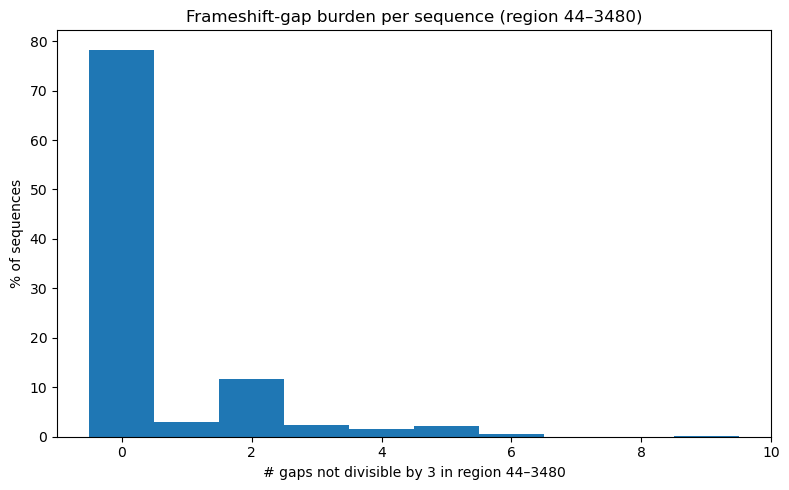

In [476]:
import matplotlib.pyplot as plt
import numpy as np

vals = df["n_not_div3_in_main"].dropna()
n_total = len(df)

bins = range(int(vals.max()) + 2)

plt.figure(figsize=(8, 5))
plt.hist(
    vals,
    bins=bins,
    align="left",
    weights=np.ones_like(vals) * 100 / n_total
)

plt.xlabel("# gaps not divisible by 3 in region 44–3480")
plt.ylabel("% of sequences")
plt.title("Frameshift-gap burden per sequence (region 44–3480)")
plt.tight_layout()
plt.show()


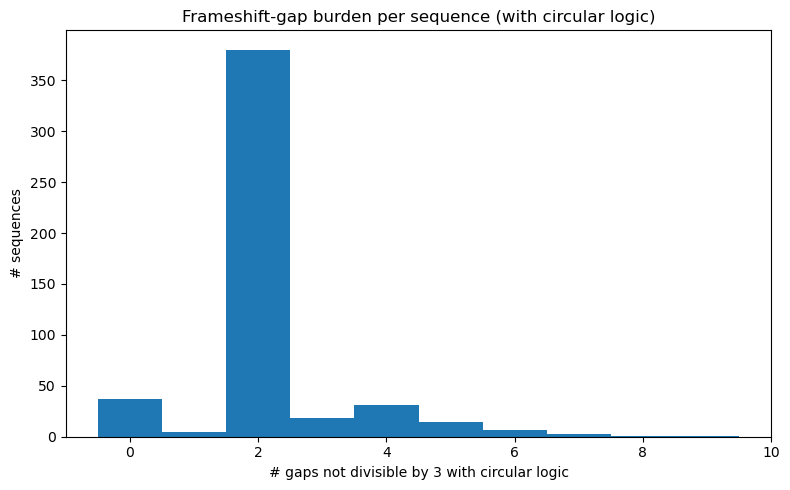

In [474]:
import matplotlib.pyplot as plt

vals = df["n_not_divisible_by_3"].dropna()

plt.figure(figsize=(8, 5))
plt.hist(vals, bins=range(int(vals.max()) + 2), align="left")
plt.xlabel("# gaps not divisible by 3 with circular logic")
plt.ylabel("# sequences")
plt.title("Frameshift-gap burden per sequence (with circular logic)")
plt.tight_layout()
plt.show()


# Stopcodons

 This plot shows me in which frame I am (the one with the least stop codons present!) !?

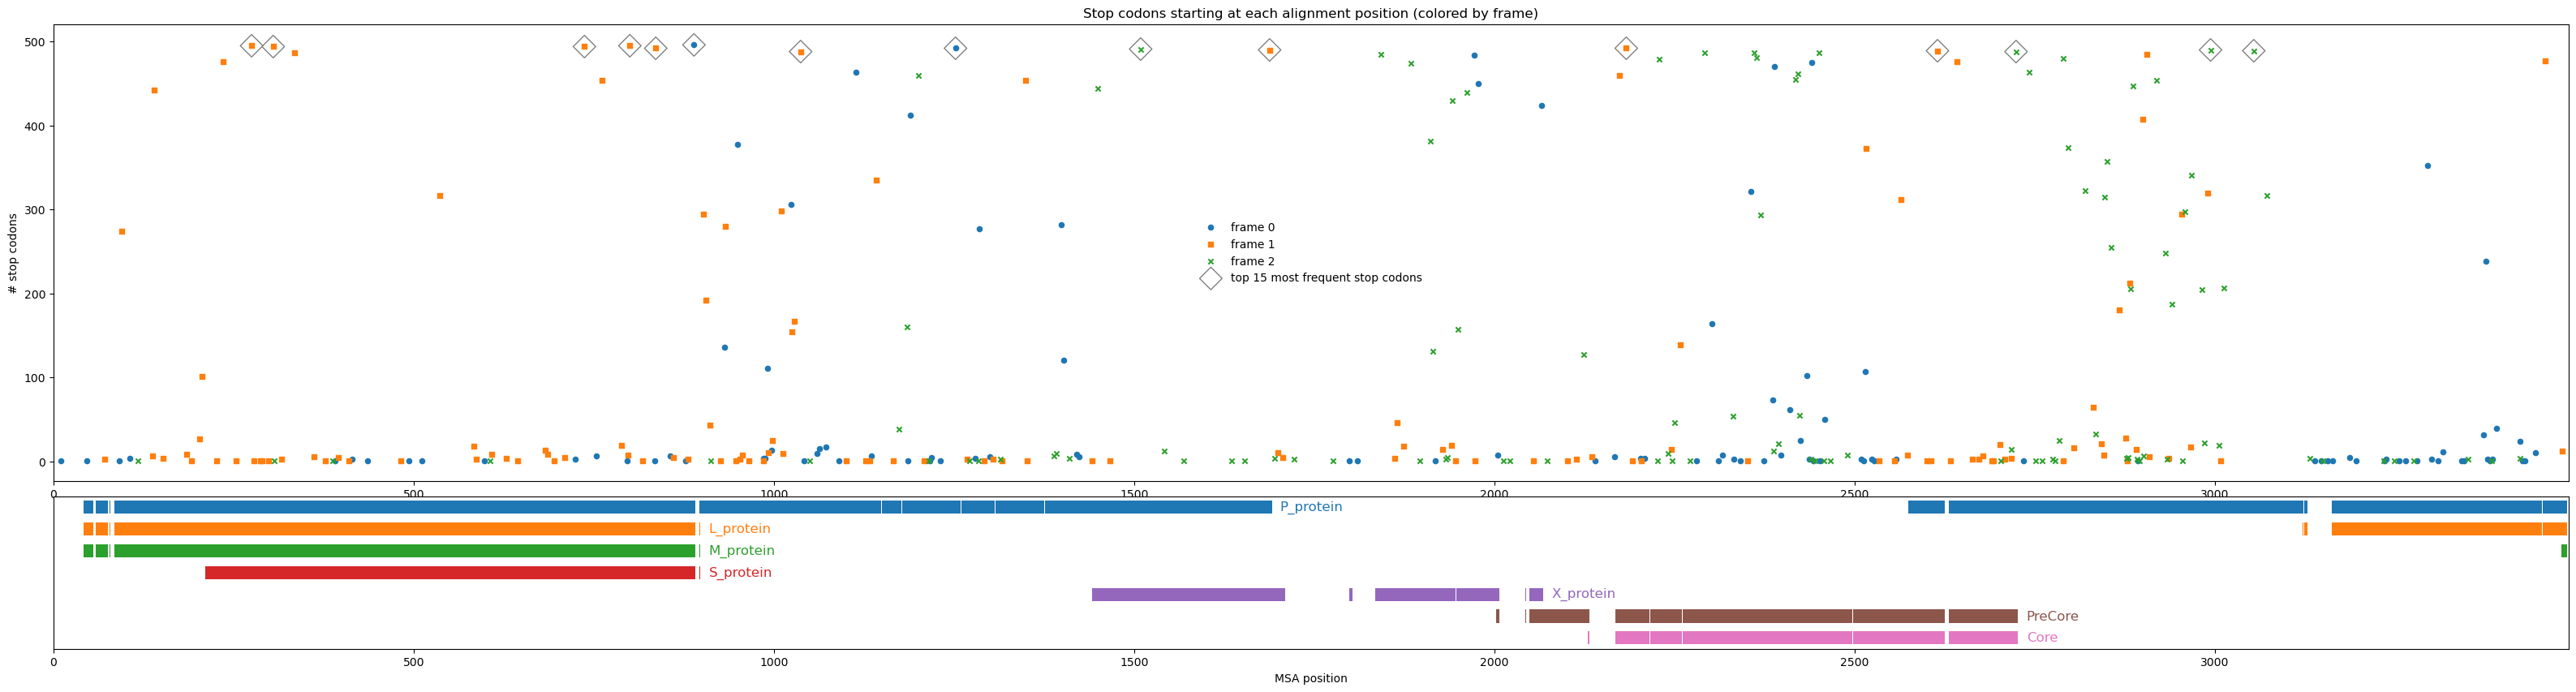

In [457]:


import numpy as np
import matplotlib.pyplot as plt

L = aln.get_alignment_length()
stops = {"TAA", "TAG", "TGA"}

counts_by_frame = np.zeros((3, L), dtype=int)

for rec in aln:
    s = str(rec.seq).upper()
    for i in range(L - 2):
        if s[i:i+3] in stops:
            frame = i % 3
            counts_by_frame[frame, i] += 1

# total stops per position
total_stops = counts_by_frame.sum(axis=0)

# top 5 positions (highest counts)
top5_idx = np.argsort(total_stops)[-15:]
top5_idx = top5_idx[np.argsort(total_stops[top5_idx])]  # optional: order by height

top5_x = x[top5_idx]
top5_y = total_stops[top5_idx]


x = np.arange(1, L + 1)

# --- figure + gridspec (ONLY top axis created here) ---
fig = plt.figure(figsize=(40, 10))
gs = fig.add_gridspec(2, 1, height_ratios=[6, 2], hspace=0.05)

ax = fig.add_subplot(gs[0, 0])

# --- top plot ---
markers = ["o", "s", "x"]
colors = ["tab:blue", "tab:orange", "tab:green"]

for frame in range(3):
    m = counts_by_frame[frame] > 0
    ax.scatter(
        x[m],
        counts_by_frame[frame][m],
        s=20,
        marker=markers[frame],
        color=colors[frame],
        label=f"frame {frame}"
    )
ax.scatter(top5_x, top5_y, s=200, marker="D",
           facecolors="none", edgecolors="grey", linewidths=1,
           label="top 15 most frequent stop codons")

ax.set_xlim(0, L)
ax.set_ylabel("# stop codons")
ax.set_title("Stop codons starting at each alignment position (colored by frame)")
ax.legend(frameon=False)

# --- bottom gene annotation track (function unchanged) ---
add_annotation_track(fig, ax, gene_msa_blocks)

plt.show()
